In [1]:
#import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

/Users/sita/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#load the fashion MNIST dataset
data = datasets.fashion_mnist
(ip_train, op_train),(ip_test, op_test) = data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
#check the shape of the images
print(ip_train.shape, ip_test.shape)
#output has three dimensions : number of images, width and height

(60000, 28, 28) (10000, 28, 28)


In [9]:
#reshape the images from having a dimension of (n, width, height) to having a new dimension(n, width, height, depth)
#images are greyscale so they are black and white, depth of 1. usually colored ones (RGB) has a depth of 3
ip_train = ip_train.reshape((60000, 28, 28, 1))
ip_test = ip_test.reshape((10000, 28, 28, 1))
print(ip_train.shape, ip_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [10]:
#prepare the data 
ip_train, ip_test = ip_train/255.0, ip_test/255.0

In [11]:
#build the network
# two extra dense layers with 128, 1000 neurons. each having ReLu activation function. also add an extra dropout layer before final layer which helps prevent overfitting
model = models.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )

In [13]:
#view the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │       129,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,490 (935.51 KB)

 Trainable params: 239,490 (935.51 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#train the model
model.fit(ip_train, op_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 804us/step - accuracy: 0.7701 - loss: 0.6353
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8583 - loss: 0.3811
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.8701 - loss: 0.3522
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 771us/step - accuracy: 0.8811 - loss: 0.3265
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - accuracy: 0.8834 - loss: 0.3106


In [15]:
#test the model
#verbose command is used to provide information about a particular task . 0 - nothing,1 = we get progress bar and number of epochs
#2 - we get only number of epochs along with loss and accuracy
model.evaluate(ip_test, op_test, verbose=2)

313/313 - 0s - 497us/step - accuracy: 0.8709 - loss: 0.3672


[0.36717209219932556, 0.8708999752998352]

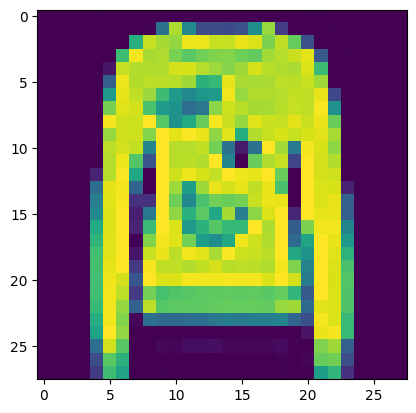

In [16]:
#carry out inference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
import matplotlib.pyplot as plt
%matplotlib inline

test_image = ip_test[5000]
plt.imshow(test_image.reshape(28,28))

In [17]:
#test the image
import numpy as np 
from tensorflow.keras.preprocessing import image 
test_image =image.img_to_array(test_image)
test_image = test_image.reshape(1,28,28,1)
result = model.predict(test_image)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


array([[1.4035685e-04, 2.9753634e-08, 9.4701225e-01, 6.1948599e-06,
        4.4297483e-02, 3.6804765e-10, 8.5431123e-03, 2.1182809e-11,
        5.6442855e-07, 4.3639600e-10]], dtype=float32)

In [18]:
np.around(result)
n=(np.around(result)).argmax()
print(n)

2


In [19]:
#find out actual clothing
print(class_names[n])

Pullover
